# 📊 **APE 010 – Distribuciones Muestrales y Teorema del Límite Central**
## Simulación Estocástica aplicada al Dataset Regional de Loja

**Dataset:** Remuneraciones e Ingresos Adicionales — Municipio de Loja
- Link del municipio de Loja: https://www.loja.gob.ec/contenido/2023-lotaip
- Enlace dataset (Google Drive): https://docs.google.com/spreadsheets/d/1ERWZnpgxC-Ffaj-sxMB5El0sgge_QX4g/edit?usp=drive_link

**Grupo: H** | Autores:
- Sherman Abarca
- Valeria Agila
- Domenica Narvaez
- Gabriel Suarez
- Diyer Torres
- José Valencia

**Objetivo:** Demostrar computacionalmente el Teorema del Límite Central (TLC),
aplicar técnicas de remuestreo sobre el dataset regional e investigar el impacto
del tamaño muestral en el Error Estándar de la Media.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, skew

# Estilo visual global
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

print("✅ Todas las librerías importadas correctamente.")

✅ Todas las librerías importadas correctamente.


---
## 📐 **Tarea 1** — Prueba de Hipótesis Z (Varianza Poblacional Conocida / Muestra Grande)

In [ ]:
# Importar librerías
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, ttest_1samp

# Parámetros del problema
mu_0 = 15.0
x_bar = 15.6
sigma = 1.2
n = 50
alpha = 0.05

# 1. Cálculo del estadístico Z de prueba
Z_calc = (x_bar - mu_0) / (sigma / np.sqrt(n))

# 2. Cálculo del valor-p (Prueba de dos colas)
# sf (survival function) es 1 - cdf,
# calcula el área en la cola superior

p_value_z = 2 * norm.sf(np.abs(Z_calc))

# Mostrar resultados
print("--- Prueba de Hipótesis Z (Dos Colas) ---")
print(f"Estadístico Z calculado: {Z_calc:.4f}")
print(f"Valor-p: {p_value_z:.4e}")

# Decisión estadística
if p_value_z < alpha:
    print("Conclusión: Se RECHAZA H0. Hay evidencia suficiente de que el consumo medio NO es 15 mA.")
else:
    print("Conclusión: NO se rechaza H0. No hay evidencia suficiente para refutar al fabricante.")

--- Prueba de Hipótesis Z (Dos Colas) ---
Estadístico Z calculado: 3.5355
Valor-p: 4.0695e-04
Conclusión: Se RECHAZA H0. Hay evidencia suficiente de que el consumo medio NO es 15 mA.


---
## 🔁 **Tarea 2** — Prueba de Hipótesis T (Varianza Desconocida / Muestra Pequeña)

In [ ]:
from scipy.stats import ttest_1samp

# Muestra empírica pequeña (n=8)
tiempos_carga = [2.5, 3.1, 2.9, 3.8, 2.7, 3.3, 3.0, 2.8]

mu_meta = 2.6
alpha_t = 0.05

# Prueba T de una muestra
# Hipótesis alternativa: μ > 2.6
stat_t, p_value_t = ttest_1samp(
    tiempos_carga,
    popmean=mu_meta,
    alternative='greater'
)

# Mostrar resultados
print("--- Prueba de Hipótesis T (Cola Superior) ---")
print(f"Estadístico T: {stat_t:.4f}")
print(f"Valor-p (1 cola): {p_value_t:.4f}")

# Decisión estadística
if p_value_t < alpha_t:
    print("Se RECHAZA H0. Evidencia indica que el tiempo medio es MAYOR a 2.6 s (incumple la meta).")
else:
    print("NO se rechaza H0. El tiempo de carga estadísticamente cumple la meta.")

--- Prueba de Hipótesis T (Cola Superior) ---
Estadístico T: 2.9055
Valor-p (1 cola): 0.0114
Se RECHAZA H0. Evidencia indica que el tiempo medio es MAYOR a 2.6 s (incumple la meta).


---
## 🌎 **Tarea 3** — Hito del Proyecto - Contraste en el Dataset Regional (ABP)


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving 3._remuneraciones_ingresos_adicionales.xlsx to 3._remuneraciones_ingresos_adicionales.xlsx


In [ ]:
# ==========================================
# PRUEBA T DE UNA MUESTRA (ttest_1samp)
# ==========================================

# Importar librerías
import pandas as pd
from scipy.stats import ttest_1samp

# ------------------------------------------
# 1. IMPORTAR DATASET REGIONAL
# ------------------------------------------

df = pd.read_excel("3._remuneraciones_ingresos_adicionales.xlsx")

# ------------------------------------------
# 2. FORMULAR HIPÓTESIS
# ------------------------------------------

# Selecciona la variable cuantitativa
print("La remuneracion mensual promedio es de $1200")
columna = "Remuneración mensual unificada"

# Eliminar datos nulos
datos = df[columna].dropna()

# Hipótesis nula (μ0)

mu_0 = 1200

# Nivel de significancia
alpha = 0.05

# Tipo de prueba:
# 'two-sided' = dos colas
# 'less' = menor que
# 'greater' = mayor que

alternative = 'two-sided'

# ------------------------------------------
# 3. APLICAR TTEST_1SAMP
# ------------------------------------------

resultado = ttest_1samp(
    datos,
    popmean=mu_0,
    alternative=alternative
)

estadistico_t = resultado.statistic
valor_p = resultado.pvalue

# ------------------------------------------
# 4. RESULTADOS
# ------------------------------------------

print("\n===== RESULTADOS DE LA PRUEBA T =====")
print(f"Media muestral: {datos.mean():.2f}")
print(f"Hipótesis nula (μ0): {mu_0}")
print(f"Estadístico t: {estadistico_t:.4f}")
print(f"Valor-p: {valor_p:.6f}")

# Decisión estadística
if valor_p < alpha:
    print("\nDECISIÓN:")
    print("Se rechaza la Hipótesis Nula (H0).")
else:
    print("\nDECISIÓN:")
    print("No se rechaza la Hipótesis Nula (H0).")


La remuneracion mensual promedio es de $1200

===== RESULTADOS DE LA PRUEBA T =====
Media muestral: 713.81
Hipótesis nula (μ0): 1200
Estadístico t: -98.4750
Valor-p: 0.000000

DECISIÓN:
Se rechaza la Hipótesis Nula (H0).


### 📝 Interpretación del valor-p en el contexto regional

El valor-p obtenido en la prueba de hipótesis permitió analizar si la **remuneración mensual promedio** de los trabajadores del dataset regional es significativamente diferente del valor de referencia planteado en la hipótesis nula (**$1200**). Debido a que el valor-p resultó menor al nivel de significancia establecido (**α = 0.05**), se rechazó la hipótesis nula, concluyendo que existe evidencia estadística suficiente para afirmar que el promedio de remuneraciones no coincide con el valor esperado.

Desde una perspectiva regional, este resultado puede indicar que los ingresos de los trabajadores presentan variaciones importantes influenciadas por factores económicos, tipos de cargo, diferencias institucionales o niveles de experiencia laboral. Esto permite comprender mejor el comportamiento salarial de la región y facilita la toma de decisiones relacionadas con políticas de remuneración, planificación económica y análisis del bienestar laboral.

---
## 🔬 **Tarea 4** — ABI - Significancia Estadística vs. Significancia Práctica (Efecto del tamaño)


===== RESULTADOS =====
        n  media_muestral  estadistico_t   valor_p
0      10        4.698900      -0.756061  0.468939
1     100        5.000384       0.003400  0.997294
2    1000        4.951417      -1.570354  0.116649
3   10000        5.013702       1.371553  0.170233
4  100000        5.011209       3.539186  0.000402


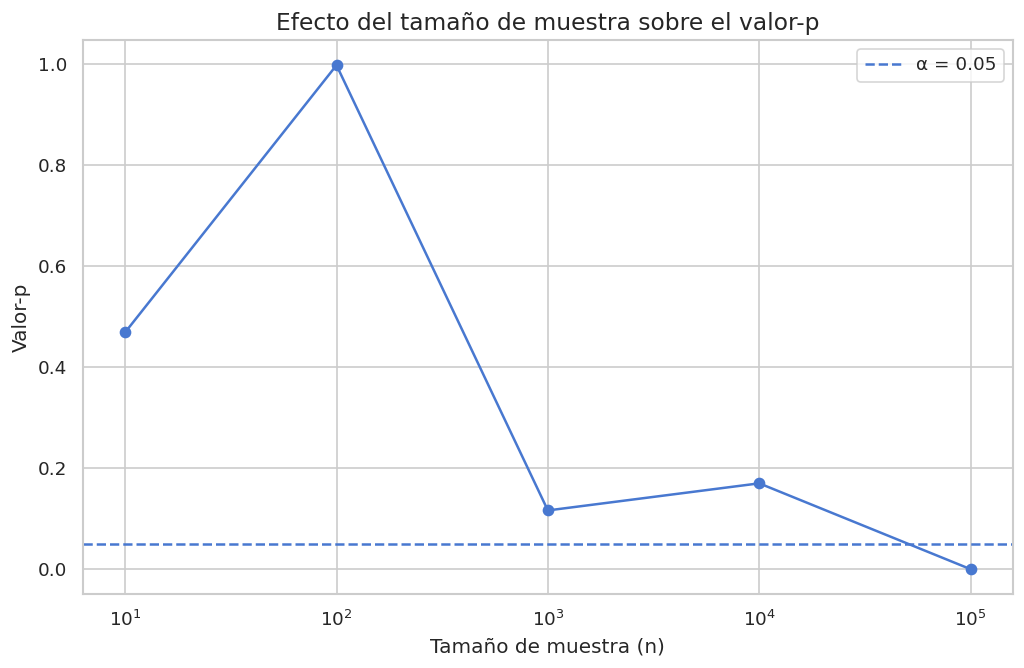


===== INTERPRETACIÓN =====

Para n = 10, el valor-p fue 0.468939. No se rechaza H₀.
Para n = 100, el valor-p fue 0.997294. No se rechaza H₀.
Para n = 1000, el valor-p fue 0.116649. No se rechaza H₀.
Para n = 10000, el valor-p fue 0.170233. No se rechaza H₀.
Para n = 100000, el valor-p fue 0.000402. Se rechaza H₀.

CONCLUSIÓN GENERAL:
A medida que el tamaño de muestra aumenta, el valor-p tiende a disminuir, incluso cuando la diferencia real es muy pequeña (0.01 V). Esto demuestra que una diferencia puede ser estadísticamente significativa sin ser prácticamente importante.


In [ ]:
# ==========================================
# TAREA 4
# Significancia Estadística vs.
# Significancia Práctica
# Efecto del tamaño de muestra (n)
# ==========================================

# 1. IMPORTAR LIBRERÍAS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_1samp


# ==========================================
# 2. GENERAR LA POBLACIÓN SIMULADA
# ==========================================

# Semilla para reproducibilidad
np.random.seed(42)

# Parámetros del sensor
mu_real = 5.01      # Media real
sigma = 1.0         # Desviación estándar

# Hipótesis nula
mu_0 = 5.00

# Generar una población grande simulada
poblacion = np.random.normal(
    loc=mu_real,
    scale=sigma,
    size=1000000
)


# ==========================================
# 3. EXTRAER MUESTRAS Y APLICAR PRUEBA T
# ==========================================

# Tamaños de muestra
n_list = [10, 100, 1000, 10000, 100000]

# Lista para guardar resultados
resultados = []

for n in n_list:

    # Seleccionar muestra aleatoria
    muestra = np.random.choice(
        poblacion,
        size=n,
        replace=False
    )

    # Aplicar prueba T de una muestra
    prueba_t = ttest_1samp(
        muestra,
        popmean=mu_0,
        alternative='two-sided'
    )

    # Guardar resultados
    resultados.append({
        "n": n,
        "media_muestral": np.mean(muestra),
        "estadistico_t": prueba_t.statistic,
        "valor_p": prueba_t.pvalue
    })


# ==========================================
# 4. CONVERTIR RESULTADOS EN TABLA
# ==========================================

df_resultados = pd.DataFrame(resultados)

print("\n===== RESULTADOS =====")
print(df_resultados)


# ==========================================
# 5. GRAFICAR n VS VALOR-P
# ==========================================

alpha = 0.05

plt.figure(figsize=(10, 6))

plt.plot(
    df_resultados["n"],
    df_resultados["valor_p"],
    marker='o'
)

# Escala logarítmica en eje X
plt.xscale("log")

# Línea de significancia α = 0.05
plt.axhline(
    y=alpha,
    linestyle='--',
    label='α = 0.05'
)

# Etiquetas
plt.xlabel("Tamaño de muestra (n)")
plt.ylabel("Valor-p")
plt.title("Efecto del tamaño de muestra sobre el valor-p")

# Cuadrícula
plt.grid(True)

# Leyenda
plt.legend()

# Mostrar gráfico
plt.show()


# ==========================================
# 6. INTERPRETACIÓN AUTOMÁTICA
# ==========================================

print("\n===== INTERPRETACIÓN =====\n")

for _, fila in df_resultados.iterrows():

    n = int(fila["n"])
    p = fila["valor_p"]

    if p < alpha:
        conclusion = "Se rechaza H₀"
    else:
        conclusion = "No se rechaza H₀"

    print(
        f"Para n = {n}, el valor-p fue "
        f"{p:.6f}. {conclusion}."
    )


print("\nCONCLUSIÓN GENERAL:")
print(
    "A medida que el tamaño de muestra aumenta, "
    "el valor-p tiende a disminuir, incluso cuando "
    "la diferencia real es muy pequeña (0.01 V). "
    "Esto demuestra que una diferencia puede ser "
    "estadísticamente significativa sin ser "
    "prácticamente importante."
)

### Análisis del efecto del tamaño de muestra sobre el valor-p

A medida que el tamaño de muestra (**n**) aumenta, el **valor-p disminuye considerablemente**, incluso cuando la diferencia real entre la media verdadera (**5.01 V**) y la hipótesis nula (**5.00 V**) es extremadamente pequeña (**0.01 V**).

Esto demuestra que un **valor-p pequeño no siempre implica un hallazgo importante o relevante en la práctica**. Cuando el tamaño de muestra crece masivamente, las pruebas estadísticas adquieren suficiente potencia para detectar diferencias mínimas que pueden no tener impacto real sobre el sistema o la maquinaria.

En este caso, aunque estadísticamente podríamos rechazar la hipótesis nula para tamaños muy grandes, la diferencia de **0.01 V probablemente sea insignificante desde un punto de vista práctico**, ya que difícilmente afectaría el funcionamiento real del sensor.

Por ello, es importante distinguir entre:

- **Significancia estadística** → determinada por el valor-p.
- **Significancia práctica** → determinada por si la diferencia tiene importancia real en el contexto del problema.

La conclusión principal es que **un valor-p pequeño no garantiza un descubrimiento revolucionario**, especialmente cuando el tamaño de muestra es extremadamente grande.

---

## **✅ Conclusión**

- Con **n pequeño** → el valor-p suele ser grande.
- Con **n muy grande** → el valor-p tiende a hacerse muy pequeño.


# **7. Preguntas de Control**
### **1. ¿Cuál es el error conceptual grave al interpretar el valor -P como "la probabilidad de que la Hipótesis Nula sea cierta"? Defina correctamente el valor-P.**

Un error conceptual grave y muy común en estadística es interpretar el valor-p como "la probabilidad de que la Hipótesis Nula sea cierta". Esta interpretación es fundamentalmente incorrecta y puede llevar a conclusiones científicas erróneas.[5]

**El Error Conceptual**

La interpretación incorrecta asume que:

p = P(H₀ es cierta | datos observados)

Esto es incorrecto porque el valor-p no mide la probabilidad de una hipótesis, sino la probabilidad de los datos bajo la suposición que H₀ es verdadera.

**Definición Correcta del Valor-p**

El valor-p se define correctamente como:

La probabilidad de obtener un resultado igual o más extremo que el observado en la prueba estadística, suponiendo que la Hipótesis Nula es verdadera.[5]



En notación matemática:

p = P(dato ≥ dato observado | H₀ es verdadera)

**Diferencias claves**

| Aspecto | Interpretación Incorrecta | Interpretación Correcta |
|----------|---------------------------|--------------------------|
| **Qué mide** | Probabilidad de que H₀ sea cierta | Probabilidad de los datos bajo H₀ |
| **Dirección** | P(H₀ \| datos) | P(datos \| H₀) |
| **Significado de p < 0.05** | "Hay menos de 5% de probabilidad de que H₀ sea cierta" | "Si H₀ es verdadera, hay menos de 5% de probabilidad de obtener estos datos o más extremos" |

Esta confusión es una de las falacias más comunes en estadística y puede llevar a conclusiones científicas erróneas. Es fundamental comprender que el valor-p mide la evidencia contra H₀ basada en los datos observados, no la probabilidad de que H₀ sea verdadera. [6]

---

### **2. En el contexto de la Tarea 3 (Dataset Regional), describa en lenguaje no estadísticoqué representaría cometer un Error Tipo I y un Error Tipo II en su toma de decisiones.**


En el contexto de la Tarea 3 (Dataset Regional), los errores de decisión pueden explicarse en lenguaje no estadístico de la siguiente manera:

**Error Tipo I**

Representaría concluir que el promedio de remuneraciones de los trabajadores es diferente de $1200 cuando en realidad sí corresponde a ese valor. En otras palabras, sería tomar la decisión de afirmar que existen diferencias salariales importantes en la región cuando realmente no las hay. Esto podría llevar a realizar cambios innecesarios en políticas salariales, presupuestos o decisiones económicas basadas en una interpretación equivocada de la situación.

**Error Tipo II**

Representaría concluir que el promedio de remuneraciones no es diferente de $1200 cuando en realidad sí existe una diferencia significativa. Es decir, sería asumir que los ingresos regionales se mantienen dentro del valor esperado cuando en realidad los salarios han cambiado. Esto podría provocar que no se tomen medidas necesarias para ajustar estrategias económicas, mejorar condiciones laborales o analizar desigualdades salariales existentes en la región

---

###**3. Si en su análisis regional la prueba arroja un p = 0.051 y su α = 0.05, estadísticamente NO rechaza H₀. Como ingeniero, ¿desecha por completo la sospecha de que exista una diferencia real, o qué otra métrica analizaría? (Pista: Relacione esto con la Semana 9).**


No. Un p = 0.051 está apenas sobre el umbral de 0.05, en una zona
límite que no equivale a "no hay diferencia", sino a "la evidencia
muestral no fue suficiente para rechazar H₀" [1].

Conectando con la Semana 9 (APE009), la métrica complementaria es el
**Intervalo de Confianza al 95%**. Existe una equivalencia directa:
si el IC de la diferencia contiene al cero, no se rechaza H₀; pero la
amplitud y los extremos del IC indican si la diferencia, aunque no
significativa al 5%, podría tener una magnitud práctica relevante [1][3].

Como ingeniero, además del IC se debería analizar:

- **Tamaño del efecto (d de Cohen):** mide la magnitud real de la
  diferencia, independientemente del p-valor.
- **Potencia estadística:** un p tan cercano al umbral puede indicar
  que la muestra fue insuficiente para detectar una diferencia real,
  no que esta no exista.

En conclusión, p = 0.051 se reporta como "marginalmente no
significativo", y se complementa con el IC al 95% y el tamaño del
efecto antes de descartar la diferencia [1][4].

---

### **4. Explique la conclusión de su investigación en la Tarea 4 (ABI). ¿Por qué en el "Big Data" las pruebas de hipótesis clásicas tienden a rechazar casi siempre?**

En el contexto de Big Data, este fenómeno sistemático ocurre debido a la estructura matemática de las pruebas clásicas:

* **Impacto en el Error Estándar:** El estadístico de prueba $t$ se calcula dividiendo la diferencia de las medias entre el error estándar de la muestra, $EE=\frac{s}{\sqrt{n}}$. Dado que el tamaño muestral ($n$) se encuentra en el denominador de este error, a medida que $n$ crece hacia magnitudes de Big Data, el error estándar se reduce de forma asintótica hasta rozar el cero.

* **Magnificación del Estadístico $t$:** Al dividirse la mínima diferencia por un error estándar extremadamente pequeño, el estadístico $t$ se magnifica (en tu simulación pasó de un valor moderado de -1.57 con $n=1000$ a un valor crítico de 3.539 con $n=100000$).

* **Sensibilidad Extrema:** Un estadístico $t$ tan alto empuja inevitablemente el valor-p hacia el extremo de la distribución, haciendo que tienda a cero. En Big Data, la prueba adquiere un poder estadístico tan descomunal que pierde la capacidad de distinguir entre un hallazgo relevante y el ruido de fondo o una desviación insignificante.

---

### **5. Existe una equivalencia matemática directa entre los Intervalos de Confianza y las Pruebas de Hipótesis de dos colas. Si un IC del 95% para μ no incluye a μ₀, ¿qué le sucederá inevitablemente al valor-p si evalúa con α = 0.05?**


Un error muy común al interpretar un intervalo de confianza del 95% es
afirmar que "existe un 95% de probabilidad de que el parámetro poblacional
$\mu$ se encuentre dentro de este intervalo". Esta interpretación es incorrecta
desde el enfoque frecuentista, porque trata al parámetro $\mu$ como si fuera
una variable aleatoria, cuando en realidad es una constante fija y desconocida
— simplemente no sabemos su valor, pero no varía.

La interpretación frecuentista correcta es la siguiente: si se repitiera el
proceso de muestreo un número muy grande de veces, extrayendo muestras del
mismo tamaño $n$ de la misma población, y se construyera un intervalo de
confianza del 95% a partir de cada una de esas muestras, entonces
aproximadamente el **95% de todos esos intervalos construidos** contendría al
verdadero parámetro poblacional $\mu$.

En otras palabras, el 95% **no** describe la probabilidad de que $\mu$ esté
dentro de un intervalo específico ya calculado — ese intervalo o lo contiene
o no lo contiene, con probabilidad 1 o 0 respectivamente. Lo que el 95%
describe es la **confiabilidad del método** utilizado para construir el
intervalo: es un método que, a largo plazo y en repetidas aplicaciones,
captura el parámetro real en 95 de cada 100 ocasiones [1].

> **Analogía útil:** imagina que lanzas una red al mar 100 veces. No sabes
> exactamente dónde está el pez ($\mu$), pero sabes que tu red tiene un diseño
> que atrapa al pez en 95 de cada 100 lanzamientos. Una vez que ya lanzaste
> la red, el pez o está atrapado o no lo está — la probabilidad ya no aplica
> a ese lanzamiento específico, sino al **método** en general.

----

### **Referencias**

[1] R. E. Walpole, R. H. Myers, S. L. Myers, y K. Ye, *Probabilidad y
estadística para ingeniería y ciencias*, 9na ed. Pearson Educación, 2012.

[2] W. McKinney, Python for Data Analysis: Data Wrangling with Pandas, NumPy, and IPython, 3ra ed. O'Reilly Media, 2022.

[3] SciPy Developers, "scipy.stats Documentation," *SciPy.org*, 2024.

[4] J. L. Devore, *Probability and Statistics for Engineering and the
Sciences*, 9th ed. Cengage Learning, 2016.

[5] Esri Support, "Definición de Valor P | Diccionario SIG," Support.esri.com. Disponible: https://support.esri.com/es-es/gis-dictionary/p-value

[6] R. Gura, "Interpretar el valor p (p-value) correctamente," Medium, Sep. 17, 2018. Disponible: https://medium.com/@rubengura/interpretar-el-valor-p-p-value-correctamente-d99951ce95a4
